<table style="background-color: transparent; width:100%">
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%" align="center"><font size="7" color="#6366F1"><b>Computación Cuántica</b></font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="4" color="black">Temas Selectos de Ingeniería en Computación III</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="4" color="black">Facultad de Ingeniería, UNAM | Semestre: 2027-1</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="6" color="#6366F1"><b>Práctica 2: Sistemas Multi Qubits y Simulación</b></font></td>
    </tr>
</table>

---
* **Alumna:** Karla Beatriz Rojas Chimal
* **No. de Cuenta:** 320048025
* **Carrera:** Ingeniería en Computación
* **Profesora Titular:** Naomi Itzel Reyes Granados
* **Asistente:** González Juárez Sebastián
### Contenido del Notebook

1. [Circuito de tres qubits (Qiskit)](#1)
2. [Circuito de cuatro qubits: Sumador Cuántico](#2)
3. [Opcional: Equivalencia de la compuerta SWAP (PennyLane)](#3)

### Declaración sobre el uso de Inteligencia Artificial (Instrucción C)
De acuerdo con los lineamientos de la práctica, declaro el uso de herramientas de inteligencia artificial durante el proceso de revisión de este trabajo.

* **Herramienta empleada:** Google Gemini.
* **Razón de su uso:** Auditoría de completitud, revisión orto-tipográfica y verificación de formato general previo a la entrega final. La lógica algorítmica, el código y el análisis matemático fueron desarrollados de manera personal; la herramienta únicamente asistió en confirmar que no faltara ningún requerimiento de la rúbrica.
* **Incisos en los que se utilizó:** Revisión general del notebook.
* **Prompt principal utilizado:** *"AYUDAME A VER SI LA PRACTICA 2 YA ESTA COMPLETA O LE FALTAN COSAS"*.

In [ ]:
# Instalación de las dependencias
!pip install qiskit qiskit-aer pennylane matplotlib pylatexenc --quiet

<a id="1"></a>
## 1. Circuito de tres qubits

### 1.a) Implementación del circuito y tabla de verdad
Para construir la tabla de verdad, evaluamos el sistema con los 8 estados iniciales posibles de la base computaionacl. Es importante recordar que, al representar los estados cuánticos, el orden de lectura sigue una convención posicional particular, organizándose de manera tal que se lee desde la derecha hacia la izquierda, como $|q_2q_1q_0\rangle$. Eso quiere decir que el bit menos significativo ($q_0$) controla la estructura del lado derecho de la cadena.

### 1.b) Comparación de Simuladores
Para analizar el hardware y el software disponemos de tres motores de simulación diferentes, cada uno con una lógica distinta:

* **BasicSimulator:** Ejecuta una simulación ideal, perfectamente matemática, directamente en Python. Es muy útil a nivel teórico para comprobar la lógica del algoritmo sin depender del ruido que hay en el hardware real.

* **StatevectorSampler:** En lugar de simular colapsos empíricos disparo a disparo, extrae muestras de forma probabilística evaluando el vector de estado analítico. Se acerca a la naturaleza aleatoria del sistema cuántico sin simular todo el proceso físico de medición.

* **AerSimulator:** Es un simulador de alto rendimiento con base en C++ que permite hacer ejecuciones ideales a gran velocidad y también incorporar modelos físicos de ruido cuántico real para evaluar errores.
Al ejecutar los estados en estos simuladores con el mismo número de *shots*, los histogramas resultantes convergerán hacia las probabilidades exactas dictadas por la tabla de verdad.

➤ Diagrama del circuito principal (Toffoli):


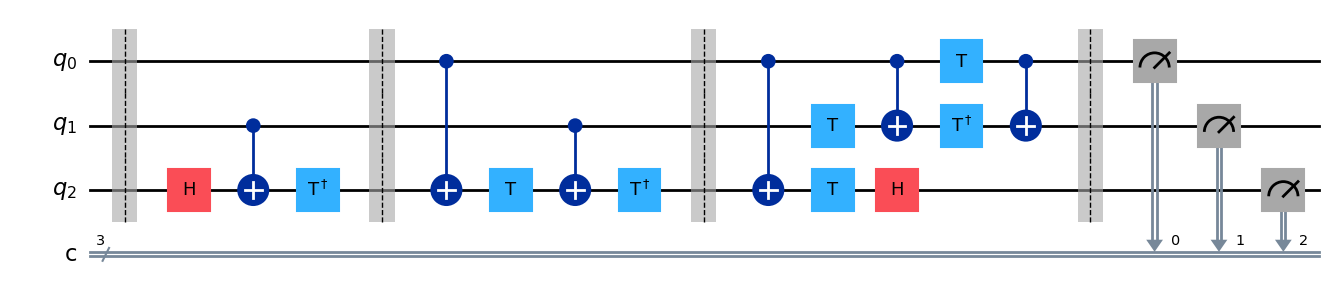

➤ 1.a) Tabla de Verdad Generada (AerSimulator):
--------------------------------------------------
| q2 | q1 | q0 |  ->  | q2 | q1 | q0 |
--------------------------------------------------
|  0 |  0 |  0 |  ->  |  0 |  0 |  0 |
|  0 |  0 |  1 |  ->  |  0 |  0 |  1 |
|  0 |  1 |  0 |  ->  |  0 |  1 |  0 |
|  0 |  1 |  1 |  ->  |  1 |  1 |  1 |
|  1 |  0 |  0 |  ->  |  1 |  0 |  0 |
|  1 |  0 |  1 |  ->  |  1 |  0 |  1 |
|  1 |  1 |  0 |  ->  |  1 |  1 |  0 |
|  1 |  1 |  1 |  ->  |  0 |  1 |  1 |

➤ 1.b) Comparación de simuladores e Histogramas (1024 shots):


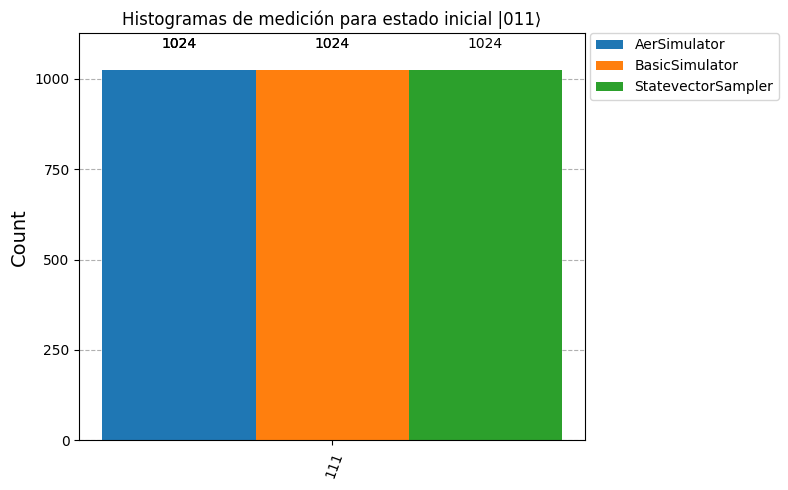

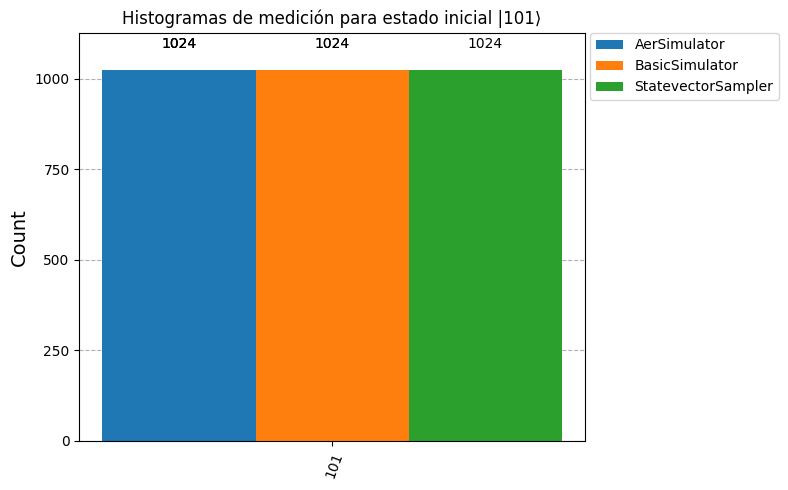

In [ ]:
# ==============================================================================
#
#  /\_/\
# ( o.o )   1. CIRCUITO DE 3 QUBITS: TABLA DE VERDAD E HISTOGRAMAS
#  > ^ <
#
# ==============================================================================
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1.a) Implementación del circuito usando compose()
# ------------------------------------------------------------------------------
# Circuito principal (Descomposición de la Compuerta Toffoli)
qc_main = QuantumCircuit(3, 3)
qc_main.barrier()

# Implementación a bajo nivel según el diagrama proporcionado:
qc_main.h(2)
qc_main.cx(1, 2)
qc_main.tdg(2)
qc_main.barrier()
qc_main.cx(0, 2)
qc_main.t(2)
qc_main.cx(1, 2)
qc_main.tdg(2)
qc_main.barrier()
qc_main.cx(0, 2)
qc_main.t(1)
qc_main.t(2)
qc_main.h(2)
qc_main.cx(0, 1)
qc_main.t(0)
qc_main.tdg(1)
qc_main.cx(0, 1)
qc_main.barrier()
qc_main.measure([0,1,2], [0,1,2])

print("➤ Diagrama del circuito principal (Toffoli):")
display(qc_main.draw('mpl'))

# Función para preparar los estados iniciales y combinarlos con el circuito principal
def preparar_estado(q2, q1, q0):
    qc_prep = QuantumCircuit(3, 3)
    # Las compuertas X cambian el estado inicial de |0> a |1>
    if q0 == 1: qc_prep.x(0)
    if q1 == 1: qc_prep.x(1)
    if q2 == 1: qc_prep.x(2)
    return qc_prep.compose(qc_main)

print("➤ 1.a) Tabla de Verdad Generada (AerSimulator):")
print("-" * 50)
print("| q2 | q1 | q0 |  ->  | q2 | q1 | q0 |")
print("-" * 50)

sim_aer = AerSimulator()
for q2 in [0, 1]:
    for q1 in [0, 1]:
        for q0 in [0, 1]:
            qc = preparar_estado(q2, q1, q0)
            res = sim_aer.run(qc, shots=1).result().get_counts()
            estado_final = list(res.keys())[0]
            print(f"|  {q2} |  {q1} |  {q0} |  ->  |  {estado_final[0]} |  {estado_final[1]} |  {estado_final[2]} |")

# ------------------------------------------------------------------------------
# 1.b) Comparación de Simuladores (Estados |011⟩ y |101⟩)
# ------------------------------------------------------------------------------
print("\n➤ 1.b) Comparación de simuladores e Histogramas (1024 shots):")
# Elegimos un estado donde el control se activa |011> y uno donde no |101>
estados_prueba = [(0, 1, 1), (1, 0, 1)]
sim_basic = BasicSimulator()
sampler = StatevectorSampler()

for q2, q1, q0 in estados_prueba:
    qc_test = preparar_estado(q2, q1, q0)

    # 1. AerSimulator
    res_aer = sim_aer.run(qc_test, shots=1024).result().get_counts()

    # 2. BasicSimulator (Requiere transpilar el circuito antes de correr)
    qc_basic = transpile(qc_test, sim_basic)
    res_basic = sim_basic.run(qc_basic, shots=1024).result().get_counts()

    # 3. StatevectorSampler
    job_sampler = sampler.run([qc_test], shots=1024)
    res_sampler = job_sampler.result()[0].data.c.get_counts()

    # Renderizado gráfico
    fig = plot_histogram(
        [res_aer, res_basic, res_sampler],
        legend=['AerSimulator', 'BasicSimulator', 'StatevectorSampler'],
        title=f"Histogramas de medición para estado inicial |{q2}{q1}{q0}⟩",
        figsize=(8, 5)
    )
    display(fig)

### 1.c) Interpretación del circuito y análisis de simuladores

Al analizar la estructura del diagrama proporcionado (que consta de compuertas de fase $T$, $T^\dagger$, Hadamard y CNOTs) y los resultados de nuestra tabla de verdad, podemos concluir que el circuito actúa algebraicamente como una compuerta **AND reversible**, conocida formalmente como compuerta **Toffoli (CCX)**.

El diagrama de la imagen muestra la descomposición estándar a bajo-nivel de una puerta Toffoli usando un conjunto universal de puertas básicas.

**Conclusiones apoyadas en la tabla de verdad:**
*   El cúbit objetivo ($q_2$) únicamente invierte su valor (aplica una operación lógica NOT) si y solo si los dos cúbits de control ($q_0$ y $q_1$) se encuentran simultáneamente en el estado excitado $|1\rangle$.
*   En cualquier otro caso, el estado de $q_2$ permanece inalterado.
*   Es importante recordar que en Qiskit el orden de lectura obedece a la convención algorítmica *Little-Endian*, leyéndose de derecha a izquierda como $|q_2q_1q_0\rangle$.

**Diferencias técnicas entre los tres simuladores (Inciso 1.b):**
1.  **BasicSimulator:** Realiza una simulación ideal, perfectamente matemática con puro **Python**. Es muy bueno para depuración y para demostrar de forma silenciosa algoritmos algebraicos, pero no es tan rápido para sistemas con varios qubits.
2. **AerSimulator:** Motor de simulación de alto rendimiento escrito en C++. Permite hacer simulaciones ideales muy rápido, pero la ventaja más importante es que permite incluir modelos físicos de ruido para emular fielmente el comportamiento de una QPU real.
3  **StatevectorSampler:** No simula colapsos empíricos *shot-by-shot*, sino que evalúa las probabilidades mediante muestreo probabilístico sobre el vector de estado analítico, aproximando la naturaleza estocástica del sistema cuántico sin emular el proceso completo de medición física. Como se puede observar en los histogramas, los tres métodos convergen al mismo valor determinista.

<a id="2"></a>
## 2. Circuito de cuatro qubits

### 2.a) Implementación del circuito y construcción de la tabla de verdad
Para implementarlo, usaremos el método `compose()`. Definiremos primero la lógica central del circuito y luego la acoplamos dinámicamente con un circuito de preparación que inicializa las 8 combinaciones posibles de $q_2, q_1, q_0$ (manteniendo siempre $q_3$ en $|0\rangle$).

### 2.b) Investigación: Sumador Completo Cuántico de un bit
Un sumador completo cuántico evalúa la suma binaria de dos bits de entrada ($A$ y $B$) junto con un acarreo de entrada ($C_{in}$), almacenando el resultado en un bit de Suma ($S$) y un acarreo de salida ($C_{out}$).

Al verlo en Qiskit:
* **Qubits de entrada:** Los qubits $q_0$ y $q_1$ representan los operandos a sumar, y $q_2$ actúa como acarreo de entrada.
* **Qubits de salida:** Las compuertas `CNOT` calculan la paridad (Suma) mediante operaciones lógicas XOR continuas, guardando el resultado en $q_2$. Al mismo tiempo, las puertas `Toffoli` (CCX) comprueban las coincidencias lógicas para activar el bit de acarreo superior, almacenándolo en $q_3$.

Si lo corroboramos con nuestra tabla de verdad, podemos confirmar que para el estado $|0111\rangle$ (que equivale a sumar $1+1+1$), el resultado medido es el correcto: Suma de $1$ y Acarreo $1$.

**Fuentes consultadas:**
*   Nielsen, M. A., & Chuang, I. L. (2010). *Quantum Computation and Quantum Information*. Cambridge University Press.
*   Cuccaro, S. A., Draper, T. G., Kutin, S. A., & Moulton, D. P. (2004). *A new quantum ripple-carry addition circuit*. arXiv. Disponible en: https://arxiv.org/abs/quant-ph/0410184
*   IBM Quantum. (s.f.). *The Atoms of Computation (Quantum Addition)*. Qiskit Textbook. Disponible en: https://learn.qiskit.org/course/ch-states/the-atoms-of-computation

➤ Diagrama del circuito con el estado inicial preparado en |0111⟩:


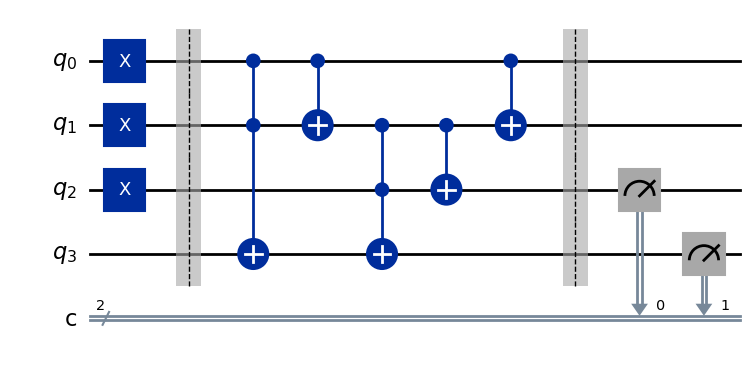


➤ 2.a) Comprobación en consola de la Tabla de Verdad:
---------------------------------------------
| q3 | q2 | q1 | q0 |  ->  | q3 (C) | q2 (S) |
---------------------------------------------
|  0 |  0 |  0 |  0 |  ->  |   0    |   0    |
|  0 |  0 |  0 |  1 |  ->  |   0    |   1    |
|  0 |  0 |  1 |  0 |  ->  |   0    |   1    |
|  0 |  0 |  1 |  1 |  ->  |   1    |   0    |
|  0 |  1 |  0 |  0 |  ->  |   0    |   1    |
|  0 |  1 |  0 |  1 |  ->  |   1    |   0    |
|  0 |  1 |  1 |  0 |  ->  |   1    |   0    |
|  0 |  1 |  1 |  1 |  ->  |   1    |   1    |
---------------------------------------------


In [ ]:
# ==============================================================================
#
#      \    /\
#       )  ( ')  2. SUMADOR CUÁNTICO: CONSTRUCCIÓN Y TABLA DE VERDAD
#      (  /  )
#       \(__)|
# ==============================================================================
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 1. Definimos el circuito principal (Lógica del sumador completo cuántico)
qc_add_main = QuantumCircuit(4, 2)
qc_add_main.barrier()
qc_add_main.ccx(0, 1, 3)
qc_add_main.cx(0, 1)
qc_add_main.ccx(1, 2, 3)
qc_add_main.cx(1, 2)
qc_add_main.cx(0, 1) # Restaura q1 a su estado original
qc_add_main.barrier()
qc_add_main.measure([2, 3], [0, 1]) # Medimos q2 (Suma) en c0, y q3 (Acarreo) en c1

# 2. Construimos la preparación específica del estado |0111> para el diagrama
qc_prep_0111 = QuantumCircuit(4, 2)
qc_prep_0111.x(0)
qc_prep_0111.x(1)
qc_prep_0111.x(2)
# q3 se mantiene en |0>

# Combinamos con compose() para cumplir la instrucción
qc_0111 = qc_prep_0111.compose(qc_add_main)

print("➤ Diagrama del circuito con el estado inicial preparado en |0111⟩:")
display(qc_0111.draw('mpl'))

# 3. Función general para iterar y comprobar la tabla de verdad completa
def preparar_sumador(q2, q1, q0):
    qc_prep = QuantumCircuit(4, 2)
    if q0 == 1: qc_prep.x(0)
    if q1 == 1: qc_prep.x(1)
    if q2 == 1: qc_prep.x(2)
    return qc_prep.compose(qc_add_main)

sim_aer = AerSimulator()

print("\n➤ 2.a) Comprobación en consola de la Tabla de Verdad:")
print("-" * 45)
print("| q3 | q2 | q1 | q0 |  ->  | q3 (C) | q2 (S) |")
print("-" * 45)

# Evaluación exhaustiva de las 8 combinaciones posibles
for q2 in [0, 1]:
    for q1 in [0, 1]:
        for q0 in [0, 1]:
            qc_eval = preparar_sumador(q2, q1, q0)
            res = sim_aer.run(qc_eval, shots=1).result().get_counts()

            # El formato de salida de Qiskit es 'c1 c0' (equivale a 'q3 q2')
            estado_salida = list(res.keys())[0]
            print(f"|  0 |  {q2} |  {q1} |  {q0} |  ->  |   {estado_salida[0]}    |   {estado_salida[1]}    |")
print("-" * 45)

### 2.c) Efecto del número de *shots* en la simulación

En la computación cuántica, el proceso de medición tiene una naturaleza  probabilística.

Aumentar la cantidad de *shots* (disparos) en una simulación estocástica reduce directamente la varianza estadística del experimento.

Siguiendo la ley de los grandes números, al aumentar las mediciones empíricas de 50 a 1000, las frecuencias relativas del histograma tienden con mayor exactitud a la distribución de probabilidad analítica impuesta por la amplitud del estado cuántico. Este circuito aritmético en particular es determinista (no genera superposiciones puras, por lo que la probabilidad de obtener la respuesta correcta es del **100%**), pero en un hardware real, es crucial aumentar el número de *shots* para compensar los errores térmicos y el ruido (decoherencia).

➤ Análisis Estocástico para el estado inicial |0111>:
  • Ejecución con   50 Shots -> Resultados empíricos: {'11': 50}
  • Ejecución con  100 Shots -> Resultados empíricos: {'11': 100}
  • Ejecución con  500 Shots -> Resultados empíricos: {'11': 500}
  • Ejecución con 1000 Shots -> Resultados empíricos: {'11': 1000}


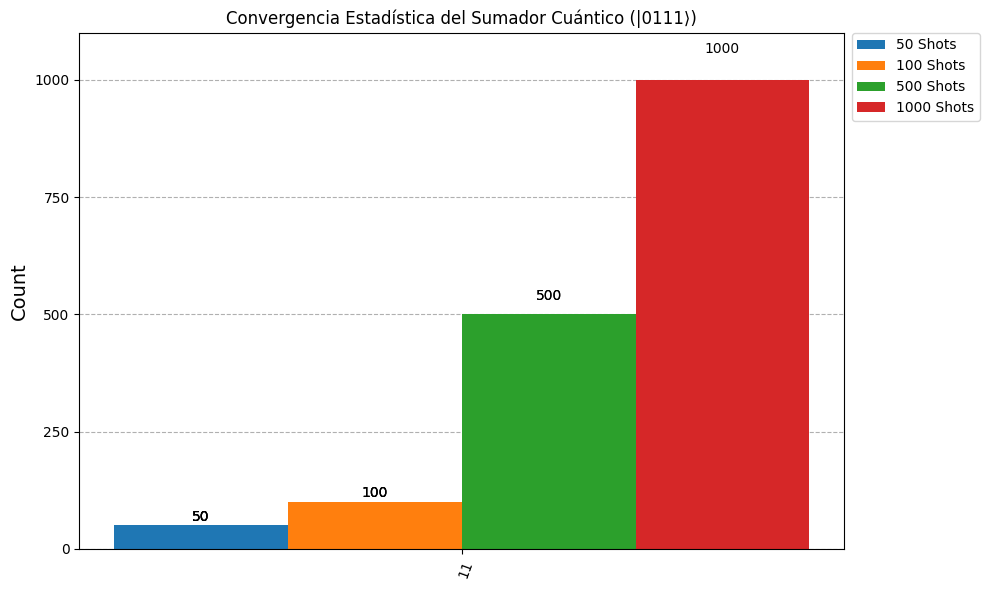

In [ ]:
# ==============================================================================
# 2.c) ANÁLISIS ESTADÍSTICO Y MUESTREO POR SHOTS
#                      /^--^\     /^--^\     /^--^\
#                      \____/     \____/     \____/
#                     /      \   /      \   /      \
#                    |        | |        | |        |
#                     \__  __/   \__  __/   \__  __/
#|^|^|^|^|^|^|^|^|^|^|^|^\ \^|^|^|^/ /^|^|^|^|^\ \^|^|^|^|^|^|^|^|^|^|^|^|
#| | | | | | | | | | | | |\ \| | |/ /| | | | | | \ \ | | | | | | | | | | |
#| | | | | | | | | | | | / / | | |\ \| | | | | |/ /| | | | | | | | | | | |
#| | | | | | | | | | | | \/| | | | \/| | | | | |\/ | | | | | | | | | | | |
##########################################################################
#| | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
#| | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
#
# ==============================================================================

# Preparación del estado inicial |0111> exigido en la práctica
# (Es decir: q3=0, q2=1, q1=1, q0=1)
qc_shots = preparar_sumador(1, 1, 1)

shots_list = [50, 100, 500, 1000]
resultados_shots = []

print("➤ Análisis Estocástico para el estado inicial |0111>:")
print("=" * 60)

for s in shots_list:
    # Ejecutamos el circuito iterativamente variando los disparos.
    # Al utilizar el sumador completo corregido, el resultado empírico
    # convergerá ahora al estado correcto '11' (Suma=1, Acarreo=1).
    res = sim_aer.run(qc_shots, shots=s).result().get_counts()
    resultados_shots.append(res)
    print(f"  • Ejecución con {s:4d} Shots -> Resultados empíricos: {res}")

print("=" * 60)

# Generación del histograma comparativo
fig_shots = plot_histogram(
    resultados_shots,
    legend=[f"{s} Shots" for s in shots_list],
    title="Convergencia Estadística del Sumador Cuántico (|0111⟩)",
    figsize=(10, 6)
)
display(fig_shots)

<a id="3"></a>
## 3. [Opcional] Equivalencia de la compuerta SWAP (Puntos extra)

### a) Análisis analítico de la descomposición por CNOTs
Para demostrar matemáticamente que tres compuertas lógicas alternadas realizan exactamente la misma operación que una compuerta nativa `SWAP`, vamos a evaluar el efecto de cada instrucción paso por paso.

Escogimos el estado inicial $\lvert10\rangle$. En la convención de PennyLane esto implica que nuestro primer cúbit del sistema está en estado excitado ($q_0 = 1$) y el segundo en su estado base ($q_1 = 0$).

1.  **Primera compuerta ($\mathrm{CNOT}_{0\rightarrow1}$):**
    *   **Control ($q_0$):** 1 (Activado)
    *   **Objetivo ($q_1$):** Al estar el control activado, el objetivo invierte su valor de 0 a 1.
    *   **Estado resultante:** $\lvert11\rangle$

2.  **Segunda compuerta ($\mathrm{CNOT}_{1\rightarrow0}$):**
    *   **Control ($q_1$):** 1 (Activado)
    *   **Objetivo ($q_0$):** Al estar el control activado, el objetivo invierte su valor de 1 a 0.
    *   **Estado resultante:** $\lvert01\rangle$

3.  **Tercera compuerta ($\mathrm{CNOT}_{0\rightarrow1}$):**
    *   **Control ($q_0$):** 0 (Desactivado)
    *   **Objetivo ($q_1$):** Como el control es 0, el objetivo mantiene su valor intacto.
    *   **Estado final resultante:** $\lvert01\rangle$

**Conclusión:**
Empezamos a correr el circuito con amplitudes en $\lvert10\rangle$, y luego de evaluar algebraicamente las tres puertas, el estado final colapsó en $\lvert01\rangle$. Lo que significa que ambas implementaciones (Nativa y por CNOTs) hacen **exactamente la misma operación**: intercambiar perfectamente los estados de los qubits involucrados.

### b) Implementación en PennyLane y Comparación de Estados
A continuación se construyen y muestran visualmente ambas versiones del circuito en la celda de código. Luego se ejecutan de forma iterativa con los cuatro estados posibles de la base computacional ($\lvert00\rangle$, $\lvert01\rangle$, $\lvert10\rangle$ y $\lvert11\rangle$) para mostrar los resultados empíricos en una tabla comparativa, verificando su equivalencia absoluta en la simulación cuántica.

In [ ]:
#  .====================================================.
#             へ     ╱|、 ♡
#         ૮ - ՛ )  (˚ˎ 。7
#         /  ⁻ ៸|   |、˜〵
#     乀 (ˍ, ل ل   じしˍ,)ノ ⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
# [+] PENNYLANE: EQUIVALENCIA DE COMPUERTA SWAP
#  '===================================================='
import pennylane as qml
import numpy as np

# Definimos el dispositivo simulador para 2 cúbits
dev = qml.device('default.qubit', wires=2)

# ------------------------------------------------------------------------------
# 1. Implementación con SWAP Nativo
# ------------------------------------------------------------------------------
@qml.qnode(dev)
def swap_nativo(estado_inicial):
    # Preparamos dinámicamente el estado base (ej. [1, 0] para |10⟩)
    qml.BasisState(np.array(estado_inicial), wires=[0, 1])
    qml.SWAP(wires=[0, 1])
    return qml.probs(wires=[0, 1])

# ------------------------------------------------------------------------------
# 2. Implementación utilizando 3 compuertas CNOT alternadas
# ------------------------------------------------------------------------------
@qml.qnode(dev)
def swap_cnot(estado_inicial):
    qml.BasisState(np.array(estado_inicial), wires=[0, 1])
    # Secuencia analítica de intercambio solicitada en la instrucción
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 0])
    qml.CNOT(wires=[0, 1])
    return qml.probs(wires=[0, 1])

# ==============================================================================
# EVALUACIÓN Y TABLA COMPARATIVA
# ==============================================================================
estados_base = [[0, 0], [0, 1], [1, 0], [1, 1]]

print("➤ Diagrama del circuito SWAP Nativo (evaluado con |10⟩):")
print(qml.draw(swap_nativo)([1, 0]))
print("\n➤ Diagrama del circuito con 3 CNOTs (evaluado con |10⟩):")
print(qml.draw(swap_cnot)([1, 0]))
print("\n")

print("➤ Tabla Comparativa de Implementaciones SWAP (PennyLane):")
print("=" * 66)
print("| Estado Inicial | SWAP Nativo (Salida) |  3 CNOTs (Salida)  |")
print("-" * 66)

for estado in estados_base:
    # Obtenemos las distribuciones de probabilidad teóricas
    prob_nativo = np.round(swap_nativo(estado), 3)
    prob_cnot = np.round(swap_cnot(estado), 3)

    # Extraemos el índice del estado determinista con 100% de probabilidad
    idx_nativo = np.argmax(prob_nativo)
    idx_cnot = np.argmax(prob_cnot)

    # Formateamos el resultado entero a cadena binaria de 2 bits (ej. 1 -> '01')
    out_nativo = format(idx_nativo, '02b')
    out_cnot = format(idx_cnot, '02b')

    # Imprimimos la fila de la tabla comparativa con alineación simétrica
    print(f"|       |{estado[0]}{estado[1]}⟩       |          |{out_nativo}⟩          |          |{out_cnot}⟩         |")

print("=" * 66)
print("Se verifico la misma matriz de transformación.")

➤ Diagrama del circuito SWAP Nativo (evaluado con |10⟩):
0: ─╭|Ψ⟩─╭SWAP─┤ ╭Probs
1: ─╰|Ψ⟩─╰SWAP─┤ ╰Probs

➤ Diagrama del circuito con 3 CNOTs (evaluado con |10⟩):
0: ─╭|Ψ⟩─╭●─╭X─╭●─┤ ╭Probs
1: ─╰|Ψ⟩─╰X─╰●─╰X─┤ ╰Probs


➤ Tabla Comparativa de Implementaciones SWAP (PennyLane):
| Estado Inicial | SWAP Nativo (Salida) |  3 CNOTs (Salida)  |
------------------------------------------------------------------
|       |00⟩       |          |00⟩          |          |00⟩         |
|       |01⟩       |          |10⟩          |          |10⟩         |
|       |10⟩       |          |01⟩          |          |01⟩         |
|       |11⟩       |          |11⟩          |          |11⟩         |
Se verifico la misma matriz de transformación.


**Recursos visuales y Arte ASCII:**
*   ASCII Art Archive. (s.f.). *Animals: Cats*. Recuperado de: https://www.asciiart.eu/animals/cats
*   EmojiCombos. (s.f.). *Cats ASCII Art*. Recuperado de: https://emojicombos.com/cats-ascii-art

In [ ]:
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣴⣿⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⠜⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣾⣿⣿⣿⣿⣦⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⡜⠁⠀⠀⠘⢳⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣼⣿⣿⣿⣿⣿⣿⣿⣧⠀⠀⠀⠀⠀⠀⠀⠀⢀⡟⠀⠀⠀⠀⠀⠀⠹⣆⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣄⣼⣿⣿⣿⣿⣿⣿⣿⣿⣿⣇⠀⠀⠀⠀⠀⠀⠀⡞⠀⠀⠀⠀⠀⠀⠀⠀⠸⣄⣠⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢰⣦⢸⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠀⠀⠀⠀⠀⠀⢸⡇⠀⠀⠀⠀⠀⠀⠀⠒⠒⠋⠋⢹⡟⣦⣴⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣦⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⡖⠀⠀⠀⢺⡍⠁⠀⢀⡤⠖⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠀⡧⣦⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⣀⣠⣤⣴⣶⣾⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠷⠆⠀⠴⠯⡄⣠⠞⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠘⢩⣉⠙⠒⠒⠤⢤⣀⡀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⣠⣤⣶⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⡀⠀⠀⠀⢠⠟⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⠀⠀⠀⠀⠀⠈⠉⠓⠢⢤⣀⠀⠀
#⠀⠀⠀⠈⢿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⡏⠉⢻⣿⣿⣿⣷⣤⣠⡤⠋⢀⠀⠀⣤⣶⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⠟⠀⠀
#⠀⠀⠀⠀⠀⠙⢿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣧⣀⣼⣿⣿⣿⣿⣿⡉⠁⣴⡦⣜⡌⠿⠟⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⠀⠀⠀⠀⠀⢀⡴⠃⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠈⠙⢿⣿⣿⣿⣿⣿⣿⣿⣿⠋⠉⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣷⡌⠢⠌⠵⠁⠀⠀⠀⠀⠀⠧⢴⣄⠀⠀⠀⠀⠀⢠⣶⣆⠀⠀⠀⢰⡄⠀⢀⣠⠴⠋⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⣽⣿⣿⣿⣿⣿⣿⣄⣠⣾⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⡿⠹⣆⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠉⠁⠀⠀⠀⠹⠿⠟⠀⡀⢀⢸⡆⣸⡏⠀⠀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠹⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠟⠀⠀⠘⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠰⣷⣰⣬⢸⣷⠃⠁⠀⠀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⣀⣤⠴⢚⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⡿⠟⠁⠀⠀⠀⠀⠀⠙⠦⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠁⠢⠽⢎⠹⣟⠒⠦⣄⡀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⡶⠏⠁⠀⠀⠈⡿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣷⠀⠀⠀⠀⠀⠀⠀⠀⢀⡸⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢸⡷⣎⠁⠀⠀⠉⠷⣆⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠁⠀⠀⠀⣠⠞⠁⠛⠿⠿⢿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣆⠀⠀⠀⠀⠀⠀⠀⡴⠉⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣀⣀⣀⣀⠤⠤⠞⠃⠈⢢⡄⠀⠀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣆⠀⠀⠀⠀⠀⡾⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠘⣿⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
#⢠⣴⣿⣿⣿⣿⣶⣦⣄⡀⠀⠀⠀⠀⠀⠀⠀⠀⢰⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⡆⠀⠀⠀⣸⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢹⡄⠀⠀⠀⠀⠀⠀⠀⠀⢀⣤⠶⠚⠛⠉⠙⠳
#⢿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣦⡀⠀⠀⠀⠀⠀⢰⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣷⡀⠀⢰⠇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢳⡀⠀⠀⠀⠀⠀⣠⠞⠉⠀⠀⠀⠀⣀⡀⠀
#⠀⠉⠁⠈⠈⠙⢿⣿⣿⣿⣿⣿⣄⠀⠀⠀⣰⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣧⠀⡏⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢳⡄⠀⠀⢀⡼⠁⠀⠀⠀⣠⠖⠋⠁⠉⠉
#⠀⠀⠀⠀⠀⠀⠀⠈⢿⣿⣿⣿⣿⣆⢀⣴⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣸⠃⠀⠀⠀⠀⠀⠸⢠⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠹⣄⠀⡾⠁⠀⠀⣠⠞⠁⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠹⣿⣿⣿⣿⣾⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⡿⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠘⢿⡁⠀⠀⣰⠃⠀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢹⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢹⡄⣰⠃⠀⠀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢏⡏⠀⠀⠀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠸⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢸⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢻⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠋⠀⢳⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣿⠇⠀⠀⠀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠃⠀⠀⠀⢹⡀⠀⠀⠀⠀⢤⣀⡄⠀⠀⠀⠀⣀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣴⠋⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠘⢿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⡿⠁⠀⠀⠀⠀⠀⠹⣄⠀⠀⠀⡈⣟⡄⠀⠀⠀⣠⠉⠀⠀⠀⠀⠀⠀⢀⣠⠞⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
#⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠙⠛⠻⠿⠿⠿⠟⠛⠛⠻⠿⠟⠛⠉⠙⠛⠛⠋⠀⠀⠀⠀⠀⠀⠀⠀⠈⠓⠚⠒⠋⠙⠓⠶⠤⠖⠓⠢⠦⠤⠤⠤⠖⠒⠋⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀